# Perancangan Model MLP untuk Kalibrasi Sensor PPG

**Tanggal kegiatan: 15 Agustus 2026**

Model XGBoost yang sudah selesai memprediksi **risiko stroke** dari profil pengguna:
usia, tekanan darah, gula darah, kolesterol, dan riwayat penyakit. Masalahnya,
nilai-nilai itu selama ini harus diukur dengan alat invasif.

Tugas MLP di sini berbeda: **menerjemahkan sinyal optik sensor menjadi nilai vital**,
sehingga pengguna tidak perlu ditusuk jarum atau dipasangi manset.

```
Sensor PPG  →  [ MLP kalibrasi ]  →  gula darah, kolesterol, asam urat,
(fitur optik)                        sistolik, diastolik
                                              ↓
                                     [ XGBoost ]  →  risiko stroke
```

Notebook ini merancang arsitekturnya beserta alasan tiap pilihan.

In [1]:
import warnings, sys
warnings.simplefilter("ignore")
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})
RANDOM_STATE = 42
print("Pustaka siap.")

Pustaka siap.



## 1. Mengapa MLP, Bukan Regresi Linier

Pertanyaan pertama: apakah hubungan fitur optik dengan nilai vital cukup lurus untuk
ditangani regresi linier?

Ada dua sifat yang membuatnya tidak lurus:

**Perfusi adalah rasio, bukan selisih.** Yang bermakna secara fisiologis bukan nilai
AC atau DC sendiri-sendiri, melainkan perbandingan keduanya (AC/DC). Pembagian tidak
dapat dinyatakan sebagai penjumlahan berbobot, sehingga regresi linier atas fitur
mentah tidak bisa menangkapnya tanpa dibuatkan kolom rasio secara manual.

**Efek perfusi dimodulasi usia.** Pembuluh darah mengeras seiring bertambahnya usia,
sehingga perfusi yang sama menghasilkan tekanan berbeda pada orang muda dan lansia.
Ini bentuk interaksi antar-fitur, yang juga tidak tertangkap model linier.

Diuji di bawah dengan data buatan yang meniru kedua sifat itu.


In [2]:

rng = np.random.default_rng(RANDOM_STATE)
n = 400

ir_dc = rng.uniform(80_000, 200_000, n)
ir_ac = rng.uniform(900, 3_200, n)
usia  = rng.uniform(20, 80, n)

perfusi  = ir_ac / ir_dc                       # rasio, bukan penjumlahan
kekakuan = 1 + (usia - 20) / 60 * 1.8          # interaksi dengan usia
sistolik = 92 + 1350 * perfusi * kekakuan + rng.normal(0, 4, n)

X  = np.column_stack([ir_dc, ir_ac, usia])
Xs = StandardScaler().fit_transform(X)

hasil = {}
for nama, model in [
    ("Regresi linier", LinearRegression()),
    ("MLP (32, 16)",   MLPRegressor(hidden_layer_sizes=(32, 16), activation="relu",
                                     max_iter=6000, random_state=RANDOM_STATE)),
]:
    pred = cross_val_predict(model, Xs, sistolik, cv=5)
    hasil[nama] = {"r2": r2_score(sistolik, pred),
                   "mae": mean_absolute_error(sistolik, pred), "pred": pred}

print(f"Sistolik buatan: rentang {sistolik.min():.0f}-{sistolik.max():.0f} mmHg\n")
print("PERBANDINGAN PADA HUBUNGAN NON-LINIER\n")
for nama, h in hasil.items():
    print(f"  {nama:18s} R2 = {h['r2']:6.4f}   MAE = {h['mae']:5.2f} mmHg")
print()
sel = hasil["MLP (32, 16)"]["r2"] - hasil["Regresi linier"]["r2"]
print(f"Selisih R2: {sel:+.4f}, MAE turun "
      f"{hasil['Regresi linier']['mae'] - hasil['MLP (32, 16)']['mae']:.2f} mmHg")
print()
print("Regresi linier tertinggal karena tidak dapat menyusun rasio AC/DC maupun")
print("interaksinya dengan usia dari fitur mentah. MLP menanganinya sendiri lewat")
print("lapisan tersembunyi, tanpa perlu kolom rasio dibuatkan manual.")


Sistolik buatan: rentang 98-209 mmHg

PERBANDINGAN PADA HUBUNGAN NON-LINIER

  Regresi linier     R2 = 0.8676   MAE =  5.68 mmHg
  MLP (32, 16)       R2 = 0.9458   MAE =  3.82 mmHg

Selisih R2: +0.0782, MAE turun 1.87 mmHg

Regresi linier tertinggal karena tidak dapat menyusun rasio AC/DC maupun
interaksinya dengan usia dari fitur mentah. MLP menanganinya sendiri lewat
lapisan tersembunyi, tanpa perlu kolom rasio dibuatkan manual.


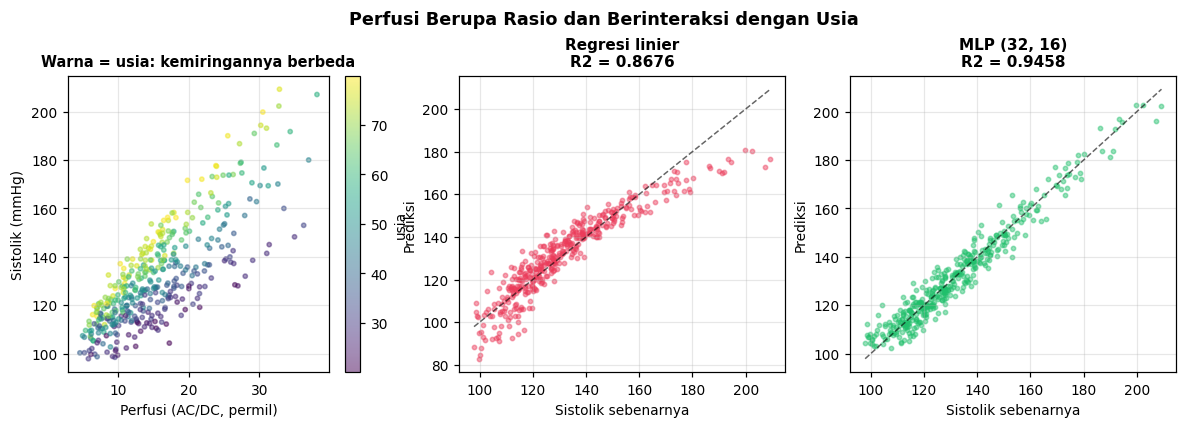

In [3]:

fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))

sc = ax[0].scatter(perfusi * 1000, sistolik, s=8, alpha=.5, c=usia, cmap="viridis")
ax[0].set_xlabel("Perfusi (AC/DC, permil)"); ax[0].set_ylabel("Sistolik (mmHg)")
ax[0].set_title("Warna = usia: kemiringannya berbeda", fontsize=9.5, fontweight="bold")
plt.colorbar(sc, ax=ax[0], label="usia")
ax[0].grid(alpha=.3)

for a, (nama, h), col in zip(ax[1:], hasil.items(), ["#eb3b5a", "#20bf6b"]):
    a.scatter(sistolik, h["pred"], s=8, alpha=.45, color=col)
    lo, hi = sistolik.min(), sistolik.max()
    a.plot([lo, hi], [lo, hi], "k--", lw=1, alpha=.6)
    a.set_xlabel("Sistolik sebenarnya"); a.set_ylabel("Prediksi")
    a.set_title(f"{nama}\nR2 = {h['r2']:.4f}", fontsize=10, fontweight="bold")
    a.grid(alpha=.3)

fig.suptitle("Perfusi Berupa Rasio dan Berinteraksi dengan Usia",
             fontsize=11.5, fontweight="bold", y=1.05)
plt.show()


## 2. Mengapa Satu Model per Parameter

Pilihan kedua: satu MLP dengan lima keluaran sekaligus, atau lima MLP terpisah?

Dipilih **lima model terpisah**, dengan tiga alasan:

**Data tiap parameter tidak sama banyaknya.** Alat kolesterol dan asam urat tidak
selalu tersedia saat pengambilan data. Kalau satu model menangani lima keluaran,
satu kolom kosong membuat seluruh baris terbuang. Dengan model terpisah, tiap
parameter memakai baris yang tersedia untuk dirinya sendiri.

**Skala nilainya jauh berbeda.** Gula darah 70–280 mg/dL, asam urat 2–9,5 mg/dL.
Dalam satu model, galat pada gula darah akan mendominasi fungsi loss dan asam urat
nyaris diabaikan.

**Kegagalan tidak menular.** Bila satu parameter gagal dilatih karena datanya
kurang, empat lainnya tetap dapat dipakai.

In [4]:
FITUR = ["ir_dc_mean", "ir_ac_p2p", "red_dc_mean", "red_ac_p2p",
         "bpm", "age_years", "gender_code"]
TARGET = {
    "gula_darah_mg_dl": "Gula Darah (mg/dL)",
    "kolesterol_mg_dl": "Kolesterol (mg/dL)",
    "asam_urat_mg_dl":  "Asam Urat (mg/dL)",
    "sistolik_mmhg":    "Sistolik (mmHg)",
    "diastolik_mmhg":   "Diastolik (mmHg)",
}

print("RANCANGAN MODEL\n")
print(f"  Fitur masukan ({len(FITUR)}):")
for f in FITUR:
    ket = {"ir_dc_mean": "intensitas rata-rata inframerah",
           "ir_ac_p2p": "amplitudo denyut inframerah",
           "red_dc_mean": "intensitas rata-rata merah",
           "red_ac_p2p": "amplitudo denyut merah",
           "bpm": "detak jantung",
           "age_years": "usia subjek",
           "gender_code": "jenis kelamin (1=L, 0=P)"}[f]
    print(f"    - {f:16s} : {ket}")
print()
print(f"  Model keluaran ({len(TARGET)}), masing-masing dilatih terpisah:")
for t, l in TARGET.items():
    print(f"    - {l}")
print()
print("Kanal hijau tidak dipakai sebagai fitur karena sinyalnya sudah AC-coupled")
print("di perangkat, sehingga nilai DC-nya tidak mencerminkan penyerapan cahaya.")

RANCANGAN MODEL

  Fitur masukan (7):
    - ir_dc_mean       : intensitas rata-rata inframerah
    - ir_ac_p2p        : amplitudo denyut inframerah
    - red_dc_mean      : intensitas rata-rata merah
    - red_ac_p2p       : amplitudo denyut merah
    - bpm              : detak jantung
    - age_years        : usia subjek
    - gender_code      : jenis kelamin (1=L, 0=P)

  Model keluaran (5), masing-masing dilatih terpisah:
    - Gula Darah (mg/dL)
    - Kolesterol (mg/dL)
    - Asam Urat (mg/dL)
    - Sistolik (mmHg)
    - Diastolik (mmHg)

Kanal hijau tidak dipakai sebagai fitur karena sinyalnya sudah AC-coupled
di perangkat, sehingga nilai DC-nya tidak mencerminkan penyerapan cahaya.


## 3. Ukuran Jaringan Diskalakan ke Jumlah Data

Ini pelajaran yang didapat dari model XGBoost: jaringan yang terlalu besar untuk
data yang sedikit tidak belajar, melainkan menghafal.

MLP dengan lapisan (64, 32) memiliki sekitar 2.625 parameter. Memaksakannya ke 5
baris data sama saja mencari 2.625 nilai dari 5 persamaan.

In [5]:
def jumlah_parameter(lapisan, n_fitur=7):
    ukuran = [n_fitur] + list(lapisan) + [1]
    return sum(ukuran[i] * ukuran[i+1] + ukuran[i+1] for i in range(len(ukuran)-1))

ATURAN = [
    ("n < 10",       (4,),     1.0,   "lbfgs"),
    ("10 <= n < 30", (16, 8),  0.1,   "lbfgs"),
    ("n >= 30",      (64, 32), 0.01,  "adam"),
]

print("ATURAN PENSKALAAN KAPASITAS MODEL\n")
print(f"{'kondisi':14s}{'lapisan':12s}{'parameter':>11}{'alpha':>8}{'solver':>9}")
print("-" * 56)
for kondisi, lapisan, alpha, solver in ATURAN:
    print(f"{kondisi:14s}{str(lapisan):12s}{jumlah_parameter(lapisan):>11}{alpha:>8}{solver:>9}")
print()
print("Alpha adalah kekuatan regularisasi: makin sedikit data, makin besar alpha")
print("agar model dipaksa mencari pola sederhana dan tidak menghafal.")
print()
print("Pemilihan solver:")
print("  lbfgs : stabil pada data kecil, mencari solusi secara langsung")
print("  adam  : lebih cepat pada data besar, dengan penghentian dini")

ATURAN PENSKALAAN KAPASITAS MODEL

kondisi       lapisan       parameter   alpha   solver
--------------------------------------------------------
n < 10        (4,)                 37     1.0    lbfgs
10 <= n < 30  (16, 8)             273     0.1    lbfgs
n >= 30       (64, 32)           2625    0.01     adam

Alpha adalah kekuatan regularisasi: makin sedikit data, makin besar alpha
agar model dipaksa mencari pola sederhana dan tidak menghafal.

Pemilihan solver:
  lbfgs : stabil pada data kecil, mencari solusi secara langsung
  adam  : lebih cepat pada data besar, dengan penghentian dini


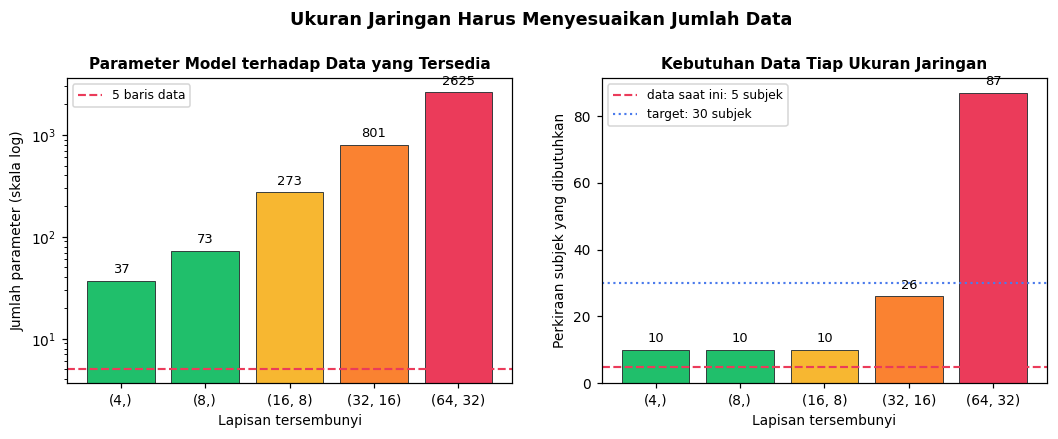

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.6))

lapisan_uji = [(4,), (8,), (16, 8), (32, 16), (64, 32)]
params = [jumlah_parameter(l) for l in lapisan_uji]
lbl = [str(l) for l in lapisan_uji]
warna = ["#20bf6b", "#20bf6b", "#f7b731", "#fa8231", "#eb3b5a"]
b = ax[0].bar(lbl, params, color=warna, edgecolor="#2d3436", linewidth=.6)
ax[0].bar_label(b, fmt="%d", fontsize=8.5, padding=3)
ax[0].axhline(5, color="#eb3b5a", ls="--", lw=1.4, label="5 baris data")
ax[0].set_yscale("log"); ax[0].set_ylabel("Jumlah parameter (skala log)")
ax[0].set_xlabel("Lapisan tersembunyi")
ax[0].set_title("Parameter Model terhadap Data yang Tersedia",
                fontsize=10, fontweight="bold")
ax[0].legend(fontsize=8)

# Berapa data yang dibutuhkan tiap ukuran, patokan 10 sampel per fitur
kebutuhan = [max(10, int(p / 30)) for p in params]
b2 = ax[1].bar(lbl, kebutuhan, color=warna, edgecolor="#2d3436", linewidth=.6)
ax[1].bar_label(b2, fmt="%d", fontsize=8.5, padding=3)
ax[1].axhline(5, color="#eb3b5a", ls="--", lw=1.4, label="data saat ini: 5 subjek")
ax[1].axhline(30, color="#4b7bec", ls=":", lw=1.4, label="target: 30 subjek")
ax[1].set_ylabel("Perkiraan subjek yang dibutuhkan")
ax[1].set_xlabel("Lapisan tersembunyi")
ax[1].set_title("Kebutuhan Data Tiap Ukuran Jaringan", fontsize=10, fontweight="bold")
ax[1].legend(fontsize=8)

fig.suptitle("Ukuran Jaringan Harus Menyesuaikan Jumlah Data",
             fontsize=11.5, fontweight="bold", y=1.05)
plt.show()

## 4. Validasi Silang Dikelompokkan per Subjek

Satu subjek dapat direkam beberapa kali dalam kondisi berbeda (puasa, sewaktu, dua
jam setelah makan). Bila rekaman orang yang sama masuk ke data latih sekaligus data
uji, model tinggal mengenali orangnya - bukan mempelajari hubungan sinyal dengan
nilai vital.

Akibatnya metrik terlihat bagus padahal modelnya hanya menghafal.

In [7]:

rng2 = np.random.default_rng(3)
n_subjek, per_subjek = 6, 5
subjek = np.repeat(np.arange(n_subjek), per_subjek)

# Tiap subjek punya ciri optik khas (sidik) dan tingkat vital khas.
# Keduanya TIDAK saling terkait -- meniru metabolisme yang berbeda antar orang.
sidik   = rng2.uniform(-2, 2, n_subjek)[subjek]
tingkat = rng2.uniform(90, 190, n_subjek)[subjek]

Xd = np.column_stack([sidik + rng2.normal(0, .03, len(subjek)),
                      rng2.normal(0, 1, len(subjek))])
yd = tingkat + rng2.normal(0, 2, len(subjek))

from sklearn.model_selection import GroupKFold
kw = dict(hidden_layer_sizes=(32, 16), max_iter=8000,
          random_state=RANDOM_STATE, alpha=.001)

r_bocor = r2_score(yd, cross_val_predict(MLPRegressor(**kw), Xd, yd, cv=LeaveOneOut()))
r_benar = r2_score(yd, cross_val_predict(MLPRegressor(**kw), Xd, yd,
                                          cv=GroupKFold(n_splits=n_subjek), groups=subjek))

print(f"{n_subjek} subjek x {per_subjek} rekaman = {len(subjek)} baris\n")
print(f"  LOO biasa (rekaman orang sama tercampur) : R2 = {r_bocor:7.3f}")
print(f"  Dikelompokkan per subjek                 : R2 = {r_benar:7.3f}")
print()
print("LOO tampak berhasil, padahal model hanya mengenali sidik optik lalu")
print("menyalin nilai vital dari rekaman lain milik orang yang sama.")
print()
print("Begitu seluruh rekaman subjek uji disembunyikan, R2 jatuh ke angka negatif:")
print("model tidak mampu menebak orang yang belum pernah dilihat sama sekali.")
print()
print(f"Selisih {r_bocor - r_benar:.1f} itulah besarnya kebocoran yang tersembunyi.")
print()
print("Aturan yang dipakai:")
print("  - Ada subjek dengan lebih dari satu rekaman -> GroupKFold per subjek")
print("  - Tiap subjek satu rekaman dan n < 30       -> LeaveOneOut")
print("  - n >= 30                                    -> 5-fold biasa")


6 subjek x 5 rekaman = 30 baris

  LOO biasa (rekaman orang sama tercampur) : R2 =   0.720
  Dikelompokkan per subjek                 : R2 =  -4.737

LOO tampak berhasil, padahal model hanya mengenali sidik optik lalu
menyalin nilai vital dari rekaman lain milik orang yang sama.

Begitu seluruh rekaman subjek uji disembunyikan, R2 jatuh ke angka negatif:
model tidak mampu menebak orang yang belum pernah dilihat sama sekali.

Selisih 5.5 itulah besarnya kebocoran yang tersembunyi.

Aturan yang dipakai:
  - Ada subjek dengan lebih dari satu rekaman -> GroupKFold per subjek
  - Tiap subjek satu rekaman dan n < 30       -> LeaveOneOut
  - n >= 30                                    -> 5-fold biasa


## 5. Ringkasan Rancangan

| Aspek | Pilihan | Alasan |
|---|---|---|
| Algoritma | MLPRegressor | Hubungan optik-fisiologis tidak linier (Beer-Lambert) |
| Jumlah model | 5 model terpisah | Ketersediaan data tiap parameter berbeda, skala nilai jauh berbeda |
| Fitur masukan | 7 | 4 fitur optik + detak jantung + usia + jenis kelamin |
| Penskalaan | StandardScaler | Nilai DC ratusan ribu, usia puluhan - harus disamakan skalanya |
| Ukuran jaringan | Menyesuaikan jumlah data | Jaringan besar pada data sedikit hanya menghafal |
| Regularisasi | Alpha membesar saat data sedikit | Memaksa model mencari pola sederhana |
| Validasi silang | Dikelompokkan per subjek | Mencegah kebocoran antar rekaman orang yang sama |

Rancangan ini diterapkan ke kode pelatihan pada kegiatan berikutnya, lalu dilatih
memakai data kalibrasi yang sudah terkumpul.